# Project - Airline AI Assistant

We'll now bring together what we've learned to make an AI Customer Support assistant for an Airline

In [1]:
# imports

import os
import json
from dotenv import load_dotenv
from openai import OpenAI
import gradio as gr
import sqlite3

c:\Users\dell\Desktop\llm_engineering_2026\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv(override=True)
api_key = os.getenv('OPENROUTER_API_KEY')

if not api_key:
    print("No API key was found - please check your .env file!")
elif not api_key.startswith("sk-or-"):
    print("API key found but it doesn't look like an OpenRoute  r key (should start with sk-or-)")
else:
    print("API key found and looks good so far!")

API key found and looks good so far!


In [ ]:
client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=api_key
    
)
MODEL = 'gpt-4.1-mini'
DB = "prices.db"

In [8]:
system_message = """
You are a helpful assistant for an Airline called FlightAI.
Give short, courteous answers, no more than 1 sentence.
Always be accurate. If you don't know the answer, say so.
"""

In [9]:
def get_ticket_price(city):
    print(f"DATABASE TOOL CALLED: Getting price for {city}", flush=True)
    with sqlite3.connect(DB) as conn:
        cursor = conn.cursor()
        cursor.execute('SELECT price FROM prices WHERE city = ?', (city.lower(),))
        result = cursor.fetchone()
        return f"Ticket price to {city} is ${result[0]}" if result else "No price data available for this city"

In [10]:
get_ticket_price("Paris")

DATABASE TOOL CALLED: Getting price for Paris


'Ticket price to Paris is $899.0'

In [11]:
price_function = {
    "name": "get_ticket_price",
    "description": "Get the price of a return ticket to the destination city.",
    "parameters": {
        "type": "object",
        "properties": {
            "destination_city": {
                "type": "string",
                "description": "The city that the customer wants to travel to",
            },
        },
        "required": ["destination_city"],
        "additionalProperties": False
    }
}
tools = [{"type": "function", "function": price_function}]
tools

[{'type': 'function',
  'function': {'name': 'get_ticket_price',
   'description': 'Get the price of a return ticket to the destination city.',
   'parameters': {'type': 'object',
    'properties': {'destination_city': {'type': 'string',
      'description': 'The city that the customer wants to travel to'}},
    'required': ['destination_city'],
    'additionalProperties': False}}}]

In [16]:

def chat(message, history):
    history = [{"role": h["role"], "content": h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = client.chat.completions.create(model=MODEL, messages=messages)
    return response.choices[0].message.content

gr.ChatInterface(fn=chat).launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [20]:
def chat(message, history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = client.chat.completions.create(model=MODEL, messages=messages, tools=tools)

    while response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        responses = handle_tool_calls(message)
        messages.append(message)
        messages.extend(responses)
        response = client.chat.completions.create(model=MODEL, messages=messages, tools=tools)
    
    return response.choices[0].message.content

In [21]:
def handle_tool_calls(message):
    responses = []
    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_ticket_price":
            arguments = json.loads(tool_call.function.arguments)
            city = arguments.get('destination_city')
            price_details = get_ticket_price(city)
            responses.append({
                "role": "tool",
                "content": price_details,
                "tool_call_id": tool_call.id
            })
    return responses

In [22]:
gr.ChatInterface(fn=chat).launch()

* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.


DATABASE TOOL CALLED: Getting price for لندن


## A bit more about what Gradio actually does:

1. Gradio constructs a frontend Svelte app based on our Python description of the UI
2. Gradio starts a server built upon the Starlette web framework listening on a free port that serves this React app
3. Gradio creates backend routes for our callbacks, like chat(), which calls our functions

And of course when Gradio generates the frontend app, it ensures that the the Submit button calls the right backend route.

That's it!

It's simple, and it has a result that feels magical.

## i have an problem with model of image generation and voice so u should try it 

## The 3 types of Gradio UI

`gr.Interface` is for standard, simple UIs

`gr.ChatInterface` is for standard ChatBot UIs

`gr.Blocks` is for custom UIs where you control the components and the callbacks

## we try gr.block with with model of text only

In [103]:
# Callbacks (along with the chat() function above)

def put_message_in_chatbot(message, history):
        return "", history + [{"role":"user", "content":message}]

# UI definition

with gr.Blocks() as ui:
    with gr.Row():
        chatbot = gr.Chatbot(height=500)
       

# Hooking up events to callbacks

    message.submit(put_message_in_chatbot, inputs=[message, chatbot], outputs=[message, chatbot]).then(
        chat, inputs=chatbot, outputs=[chatbot]
    )

ui.launch(inbrowser=True, auth=("ed", "bananas"))

c:\Users\dell\Desktop\llm_engineering_2026\.venv\Lib\site-packages\gradio\utils.py:1200: UserWarning: Expected 2 arguments for function <function chat at 0x0000024DE38DDD20>, received 1.
  warnings.warn(
c:\Users\dell\Desktop\llm_engineering_2026\.venv\Lib\site-packages\gradio\utils.py:1204: UserWarning: Expected at least 2 arguments for function <function chat at 0x0000024DE38DDD20>, received 1.
  warnings.warn(


* Running on local URL:  http://127.0.0.1:7864
* To create a public link, set `share=True` in `launch()`.


## i used openrouter to generate image because i dont use openai but openrouter has a problem in imgage generaror but i use SVG

In [104]:
from dotenv import load_dotenv
from IPython.display import Markdown, display
from datetime import datetime
import time
from revealer import reveal
from openai import OpenAI
import os
load_dotenv(override=True)

True

In [116]:
def artist(model, city, effort=None):
    
    prompt = f"""
Generate ONLY a valid SVG image.

The SVG should represent a vacation in {city}, showing:
- famous tourist spots
- landmarks unique to {city}
- vibrant pop-art style
- lively atmosphere

Do NOT include explanations, markdown, or code blocks.
Return ONLY raw SVG.
"""

    response = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        reasoning_effort=effort
    )

    return response.choices[0].message.content

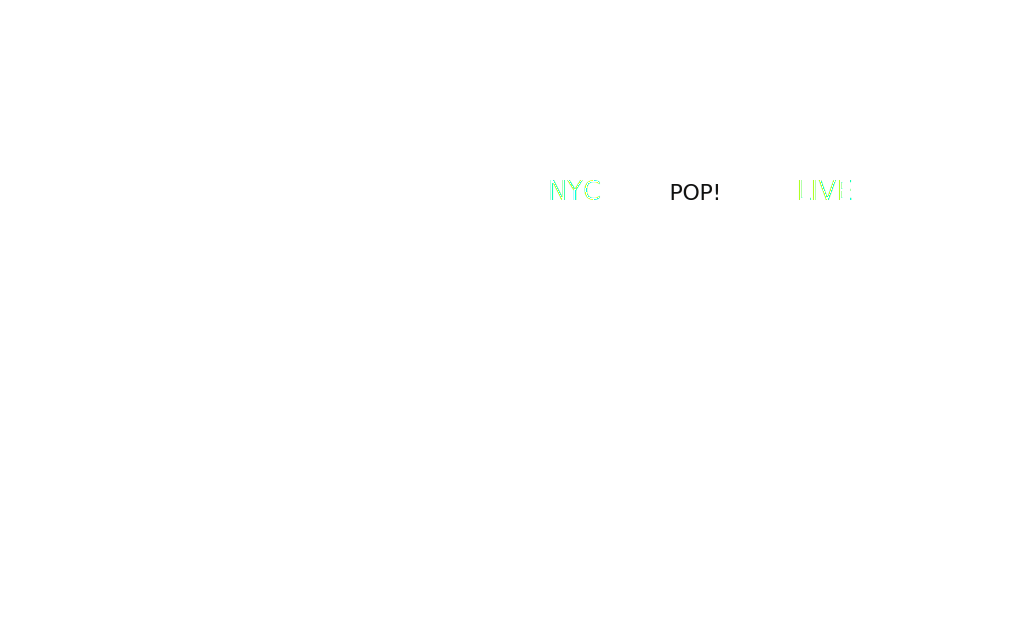

In [118]:
svg = artist("openai/gpt-5-nano", "New York City", effort="low")
reveal(svg)